# F1 AI Strategy Simulator

## Step 7 — Monte Carlo Race Simulation

In this notebook we extend the race simulator to perform Monte Carlo simulation.

Monte Carlo simulation runs the same race many times with randomness
in overtakes, pit stops, and race pace.

By running hundreds or thousands of simulations we can estimate:

- Win probability
- Podium probability
- Top 5 probability
- Average finishing position

This transforms the simulator into a probabilistic race strategy engine.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

## Load Trained Models

In [2]:
lap_model = joblib.load("../models/lap_time_model.pkl")
overtake_model = joblib.load("../models/overtake_model.pkl")
pit_model = joblib.load("../models/pit_stop_model.pkl")

print("Models loaded successfully")

Models loaded successfully


## Load Base Dataset

In [3]:
df = pd.read_csv("../data/feature_dataset.csv")

print("Dataset loaded:", df.shape)

Dataset loaded: (145913, 28)


In [8]:
race_df = df[df["Season"] == 2024]

race_df = race_df.sort_values(
    ["TrackEncoded","DriverEncoded","LapNumber"]
)

## Simulation Parameters

In [9]:
TOTAL_LAPS = int(race_df["LapNumber"].max())

PIT_TIME_LOSS = 20
DRS_THRESHOLD = 1.0
FUEL_BURN_PER_LAP = 1.7

N_SIMULATIONS = 1000

## Tire Degradation Model

In [10]:
def tire_penalty(age):
    return 0.04 * age + 0.002 * age**2

## Race Simulation Function

This function runs one full race simulation using the ML models.

In [11]:
def simulate_race():

    race_state = (
        df[df["Season"] == 2024]
        .sort_values(["TrackEncoded","DriverEncoded","LapNumber"])
        .groupby("DriverEncoded")
        .first()
        .reset_index()
    )

    race_state = race_state.sort_values("Position").reset_index(drop=True)

    race_state["cumulative_time"] = 0.0
    race_state["gap_ahead"] = 0.0
    race_state["gap_behind"] = 0.0
    race_state["traffic_pressure"] = 0.0
    race_state["drs_available"] = 0

    for lap in range(1, TOTAL_LAPS + 1):

        race_state["LapNumber"] = lap
        race_state["lap_progress"] = lap / TOTAL_LAPS

        # Tire ageing
        race_state["tyre_age"] += 1
        race_state["laps_since_pit"] += 1

        # Fuel burn
        race_state["fuel_load"] -= FUEL_BURN_PER_LAP
        race_state["fuel_load"] = race_state["fuel_load"].clip(lower=0)

        # Track evolution
        race_state["track_evolution"] = lap / TOTAL_LAPS

        # =============================
        # LAP TIME MODEL
        # =============================

        lap_features = race_state[
        [
        'DriverEncoded','TeamEncoded','TrackEncoded','Season','RegulationEra',
        'LapNumber','lap_progress','Position','CompoundEncoded','tyre_age',
        'stint_number','pace_trend','laps_since_pit','fuel_load','track_evolution',
        'AirTemp','TrackTemp','Humidity','WindSpeed','gap_ahead','gap_behind',
        'traffic_pressure','drs_available','driver_pace_baseline',
        'track_pace_baseline','pace_relative'
        ]
        ].fillna(0)

        race_state["lap_time"] = lap_model.predict(lap_features)

        # Tire degradation
        race_state["lap_time"] += race_state["tyre_age"].apply(tire_penalty)

        # Fuel weight
        race_state["lap_time"] += race_state["fuel_load"] * 0.025

        # Team performance variation
        team_strength = ((race_state["TeamEncoded"] % 6) - 3) * 0.15
        race_state["lap_time"] += team_strength

        # Driver variability
        driver_error = np.random.normal(0,0.30,len(race_state))
        driver_error = np.clip(driver_error,-0.8,0.8)

        race_state["lap_time"] += driver_error

        # Dirty air
        dirty_air = np.where(race_state["gap_ahead"] < 1.5,0.35,0)
        race_state["lap_time"] += dirty_air

        # DRS boost
        drs_boost = np.where(race_state["drs_available"]==1,-0.20,0)
        race_state["lap_time"] += drs_boost

        # =============================
        # PIT MODEL FEATURES
        # =============================

        race_state["compound_stint_age"] = race_state["CompoundEncoded"] * race_state["tyre_age"]

        race_state["pit_window_pressure"] = (
            race_state["laps_since_pit"] /
            (race_state["laps_since_pit"] + 10)
        )

        race_state["pace_drop"] = (
            race_state["pace_trend"] -
            race_state["driver_pace_baseline"]
        )

        race_state["stint_progress"] = (
            race_state["laps_since_pit"] /
            (race_state["laps_since_pit"].max() + 1)
        )

        race_state["undercut_pressure"] = (race_state["gap_ahead"] < 2).astype(int)

        race_state["track_pit_rate"] = 0.05

        pit_features = race_state[
        [
        "DriverEncoded","TrackEncoded","Season","Position",
        "CompoundEncoded","tyre_age","stint_number",
        "laps_since_pit","stint_progress","pace_trend",
        "pace_drop","fuel_load","track_evolution",
        "gap_ahead","gap_behind","traffic_pressure",
        "undercut_pressure","compound_stint_age",
        "track_pit_rate","pit_window_pressure"
        ]
        ].fillna(0)

        pit_prob = pit_model.predict_proba(pit_features)[:,1]

        race_state["pit_stop"] = (
            (np.random.rand(len(race_state)) < pit_prob) &
            (race_state["tyre_age"] > 8)
        )

        race_state.loc[race_state["pit_stop"],"lap_time"] += PIT_TIME_LOSS
        race_state.loc[race_state["pit_stop"],"tyre_age"] = 0
        race_state.loc[race_state["pit_stop"],"laps_since_pit"] = 0
        race_state.loc[race_state["pit_stop"],"stint_number"] += 1

        # Update race time
        race_state["cumulative_time"] += race_state["lap_time"]

        # Update order
        race_state = race_state.sort_values("cumulative_time").reset_index(drop=True)
        race_state["Position"] = np.arange(1,len(race_state)+1)

        # Gap calculations
        race_state["gap_ahead"] = (
            race_state["cumulative_time"] -
            race_state["cumulative_time"].shift(1)
        ).fillna(0)

        race_state["gap_behind"] = (
            race_state["cumulative_time"].shift(-1) -
            race_state["cumulative_time"]
        ).fillna(0)

        race_state["traffic_pressure"] = race_state["gap_ahead"] - race_state["gap_behind"]

        race_state["drs_available"] = (race_state["gap_ahead"] < DRS_THRESHOLD).astype(int)

        # =============================
        # OVERTAKE MODEL
        # =============================

        race_state["pace_diff"] = race_state["pace_trend"].diff().fillna(0)
        race_state["tyre_advantage"] = race_state["tyre_age"].diff().fillna(0)

        race_state["close_battle"] = (race_state["gap_ahead"] < 1.2).astype(int)

        race_state["closing_speed"] = (
            race_state["gap_ahead"].shift(1) -
            race_state["gap_ahead"]
        ).fillna(0)

        race_state["drs_pressure"] = (
            race_state["drs_available"] *
            np.maximum(0,1-race_state["gap_ahead"])
        )

        race_state["track_overtake_rate"] = 0.15

        overtake_features = race_state[
        [
        "DriverEncoded","TrackEncoded","Season","Position",
        "CompoundEncoded","tyre_age","pace_trend",
        "gap_ahead","gap_behind","traffic_pressure",
        "laps_since_pit","drs_available",
        "pace_diff","tyre_advantage","close_battle",
        "closing_speed","drs_pressure","track_overtake_rate"
        ]
        ].fillna(0)

        overtake_prob = overtake_model.predict_proba(overtake_features)[:,1]

        race_state["overtake"] = np.random.rand(len(race_state)) < overtake_prob

        for i in range(1,len(race_state)):
            if race_state.loc[i,"overtake"] and race_state.loc[i,"gap_ahead"] < 1.2:
                race_state.iloc[[i-1,i]] = race_state.iloc[[i,i-1]].values

    return race_state[["DriverEncoded","Position"]]

## Run Monte Carlo Simulation

In [12]:
all_results = []

for sim in range(N_SIMULATIONS):

    race_result = simulate_race()

    race_result["simulation"] = sim

    all_results.append(race_result)

    if sim % 50 == 0:
        print(f"Simulation {sim}/{N_SIMULATIONS}")

Simulation 0/1000
Simulation 50/1000
Simulation 100/1000
Simulation 150/1000
Simulation 200/1000
Simulation 250/1000
Simulation 300/1000
Simulation 350/1000
Simulation 400/1000
Simulation 450/1000
Simulation 500/1000
Simulation 550/1000
Simulation 600/1000
Simulation 650/1000
Simulation 700/1000
Simulation 750/1000
Simulation 800/1000
Simulation 850/1000
Simulation 900/1000
Simulation 950/1000


## Combine Results

In [13]:
results_df = pd.concat(all_results)

## Win Probability

In [14]:
wins = results_df[results_df["Position"] == 1]

win_prob = wins["DriverEncoded"].value_counts() / N_SIMULATIONS

win_prob

DriverEncoded
36    0.596
30    0.377
21    0.027
Name: count, dtype: float64

## Podium Probability

In [15]:
podiums = results_df[results_df["Position"] <= 3]

podium_prob = podiums["DriverEncoded"].value_counts() / N_SIMULATIONS

podium_prob

DriverEncoded
30    1.000
36    1.000
21    0.987
9     0.012
38    0.001
Name: count, dtype: float64

## Top 5 Probability

In [16]:
top5 = results_df[results_df["Position"] <= 5]

top5_prob = top5["DriverEncoded"].value_counts() / N_SIMULATIONS

top5_prob

DriverEncoded
21    1.000
30    1.000
36    1.000
9     0.993
32    0.349
38    0.271
25    0.182
15    0.132
4     0.068
22    0.003
35    0.001
16    0.001
Name: count, dtype: float64

## Average Finishing Position

In [17]:
avg_position = results_df.groupby("DriverEncoded")["Position"].mean()

avg_position.sort_values()

DriverEncoded
36     1.459
30     1.719
21     2.835
9      4.094
32     6.016
25     6.678
15     8.338
4      9.046
38     9.361
16     9.804
22     9.900
35    12.183
11    12.356
27    14.049
33    14.509
34    15.702
6     15.816
20    18.145
28    18.298
2     19.701
7     21.456
26    21.696
31    23.124
1     23.715
Name: Position, dtype: float64

## Win Probability Visualization

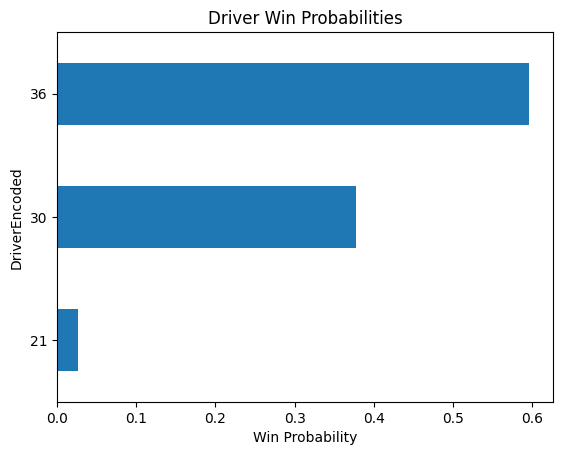

In [18]:
win_prob.sort_values().plot(kind="barh")

plt.xlabel("Win Probability")
plt.title("Driver Win Probabilities")

plt.show()

## Save Monte Carlo Results

In [19]:
results_df.to_csv("../data/monte_carlo_results.csv", index=False)

print("Monte Carlo results saved")

Monte Carlo results saved


## What to do when you reopen the notebook PART B.
PART A — Simulation (slow, 50 min)
PART B — Analysis / visualization (1 second)
## The golden rule

Never press Run All in Step 7 after simulations are saved.

which is the 50-minute computation.

Just run these 3 small steps.

1️⃣ Load Monte Carlo results (PART B NOW)

In [32]:
import pandas as pd

results_df = pd.read_csv("../data/monte_carlo_results.csv")

print(results_df.shape)
results_df.head()

(24000, 3)


,DriverEncoded,Position,simulation
0,21,1,0
1,30,2,0
2,36,3,0
3,9,4,0
4,25,5,0


## 2️⃣ Recompute probabilities

In [33]:
print(df.columns)

N_SIMULATIONS = results_df["simulation"].nunique()

wins = results_df[results_df["Position"] == 1]
win_prob = wins["DriverEncoded"].value_counts() / N_SIMULATIONS

podiums = results_df[results_df["Position"] <= 3]
podium_prob = podiums["DriverEncoded"].value_counts() / N_SIMULATIONS

top5 = results_df[results_df["Position"] <= 5]
top5_prob = top5["DriverEncoded"].value_counts() / N_SIMULATIONS

avg_position = results_df.groupby("DriverEncoded")["Position"].mean()

Index(['Driver', 'DriverEncoded', 'TeamEncoded', 'TrackEncoded', 'Season',
       'RegulationEra', 'LapNumber', 'lap_progress', 'Position',
       'CompoundEncoded', 'tyre_age', 'stint_number', 'pace_trend',
       'laps_since_pit', 'fuel_load', 'track_evolution', 'AirTemp',
       'TrackTemp', 'Humidity', 'WindSpeed', 'race_time', 'gap_ahead',
       'gap_behind', 'traffic_pressure', 'drs_available',
       'driver_pace_baseline', 'track_pace_baseline', 'pace_relative',
       'LapTimeSeconds'],
      dtype='object')


## 2️⃣ Recompute probabilities && 2️⃣ Recompute probabilities

In [30]:
df = pd.read_csv("../data/feature_dataset.csv")

race_df = df[df["Season"] == 2024]

driver_map = (
    race_df[["DriverEncoded","Driver"]]
    .drop_duplicates()
    .set_index("DriverEncoded")["Driver"]
    .to_dict()
)

win_prob_named = win_prob.rename(index=driver_map)
podium_prob_named = podium_prob.rename(index=driver_map)
top5_prob_named = top5_prob.rename(index=driver_map)
avg_position_named = avg_position.rename(index=driver_map)

## 5️⃣ Print results

In [31]:
print("Win Probability")
print(win_prob_named.sort_values(ascending=False))

print("\nPodium Probability")
print(podium_prob_named.sort_values(ascending=False))

print("\nTop 5 Probability")
print(top5_prob_named.sort_values(ascending=False))

print("\nAverage Position")
print(avg_position_named.sort_values())

Win Probability
DriverEncoded
VER    0.596
RIC    0.377
LEC    0.027
Name: count, dtype: float64

Podium Probability
DriverEncoded
RIC    1.000
VER    1.000
LEC    0.987
DOO    0.012
ZHO    0.001
Name: count, dtype: float64

Top 5 Probability
DriverEncoded
LEC    1.000
RIC    1.000
VER    1.000
DOO    0.993
SAI    0.349
ZHO    0.271
NOR    0.182
HAM    0.132
BEA    0.068
MAG    0.003
TSU    0.001
HUL    0.001
Name: count, dtype: float64

Average Position
DriverEncoded
VER     1.459
RIC     1.719
LEC     2.835
DOO     4.094
SAI     6.016
NOR     6.678
HAM     8.338
BEA     9.046
ZHO     9.361
HUL     9.804
MAG     9.900
TSU    12.183
GAS    12.356
PER    14.049
SAR    14.509
STR    15.702
BOT    15.816
LAW    18.145
PIA    18.298
ALO    19.701
COL    21.456
OCO    21.696
RUS    23.124
ALB    23.715
Name: Position, dtype: float64


## Donot run the entire cell just run above only 